In [4]:
import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()



import os

def create_subfolders(parent_directory, subfolder_names, nested_subfolder_names):
    for folder_name in subfolder_names:
        # Construct the full path for the new subfolder
        subfolder_path = os.path.join(parent_directory, folder_name)
        try:
            # Create the main subfolder
            os.makedirs(subfolder_path)
            print(f"Created subfolder: {subfolder_path}")

            # Create nested subfolders
            for nested_folder_name in nested_subfolder_names:
                nested_subfolder_path = os.path.join(subfolder_path, nested_folder_name)
                os.makedirs(nested_subfolder_path)
                print(f"Created nested subfolder: {nested_subfolder_path}")
        except OSError as error:
            print(f"Error creating subfolder {subfolder_path}: {error}")


def proj_X_opt(x):
    """
    Project point x = (x1, x2) onto
    X = { (u,v) | u >= 0, v >= 0, u+v <= 1 }
    """
    x = np.asarray(x)

    # Objective: minimize squared distance
    def objective(u):
        return 0.5 * np.sum((u - x)**2)

    # Constraints
    constraints = [
        {"type": "ineq", "fun": lambda u: 1 - u[0] - u[1]} # u+v <= 15
    ]

    # Initial guess
    z0 = np.maximum(x, 0)  # clip negative values to start inside nonnegative orthant
    bounds = [(0, 1), (0, 1)]

    result = minimize(objective, z0, constraints=constraints)

    return result.x


def const(x):
    return 1-(x[0]+x[1])


# ------------------- Projected gradient VI solver -------------------
n_runs= 10
def vi_solver(l, step=0.001, max_iter=200, tol=1e-4):
    x0= np.random.uniform(0, 1, size=2)
    x = x0.copy()
    for _ in range(max_iter):
        x_new = proj_X_opt(x - step * F(x, l))
        if np.linalg.norm(x_new - x) < tol:
            if np.linalg.norm(const(x_new)*l)<= 1e-6:
                return x_new
        x = x_new
    if np.linalg.norm(const(x_new)*l)<= 1e-6:
        return x_new
    else:
        return None



def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])

def gradient_x1(x):
    return 1.0

def gradient_x2(x):
    return 1.0

def gradient(x):
    return np.array([gradient_x1(x),gradient_x2(x)])
def F(x, lamd):
    return np.array([-1+lamd*gradient_x1(x),-2+lamd*gradient_x2(x)])
n= 2
alpha= np.random.uniform(0, sqrt(2)-1)
# alpha= sqrt(2)-1
alpha




def project_into_feasible_set(x,constraint_function):
    result = minimize(lambda x_prime: np.linalg.norm(x_prime - x), x, constraints={'type': 'ineq', 'fun': constraint_function},bounds= [(0,1),(0,1)])
    return result.x

num_iterations= 100
def projected_gradient_descent_kkt(F,initial_x, initial_y, lambda_value,lamd):
    x = initial_x.copy()
    y = initial_y.copy()


    grad_obj = F(y,lamd)
    x = project_into_feasible_set(x -  lambda_value *grad_obj, constraint_function)
    return x


def vi_solver(lamd):
    n= 2
    x0= np.random.uniform(0, 1, size=n)
    y0= x0.copy()

    T= 1000
    x,y= np.zeros((T+1,n)),np.zeros((T+1,n))
    x[0]= x0
    y[0]= y0
    lambda_value_0= np.random.uniform(0, alpha)
#     print(x0)
    x[1]= projected_gradient_descent_kkt(F,x[0], y[0], lambda_value_0, lamd)
    y[1]= 2*x[1]-x[0]
    for i in range(1,T):

        if np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))!= 0.0:
            lambda_value= np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd)))
        else:
            lambda_value= 1e-8 # np.random.uniform(0, (alpha*np.linalg.norm(y[i] - y[i-1]))/np.linalg.norm(F(y[i],lamd) - F(y[i-1],lamd))+1e-8)
      # break
#         print(x[i])
        x[i+1]= projected_gradient_descent_kkt(F,x[i], y[i], lambda_value,lamd)
        y[i+1]= 2*x[i+1]-x[i]
#         print(x[i+1])
        
#         print(np.linalg.norm(x[i+1] - x[i]))
        
        if (np.linalg.norm(x[i+1] - x[i])) <= 1e-4:
#             np.linalg.norm(x[i+1] - y[i]) <= 1e-4):
            print(f"Converged at iteration {i}")
    
            if np.abs(const(x[i+1]) * lamd) <= 1e-6:
                return x[i+1]
            
            
    
#             if lambda_value== 0.0:
#                 return x[i+1]
#             if np.linalg.norm(const(x[i+1])*lambda_value)<= 1e-6:
#                 return x[i+1]
#             elif np.abs(const(x[i+1])) < 1e-6:
#                 return x[i+1]
#             elif x[i] < 1e-12:
#                 return None
#             else:
#                 return None
#         else:
#             return None
    #print(const(x[T])) 
    
#     if lambda_value== 0.0:
#         return x[T]
#     if np.linalg.norm(const(x[T])*lambda_value)<= 1e-6:
# #     if const(x[T])<= 1e-6:
#         return x[T]
#     elif np.abs(const(x[T])).all() < 1e-6:
#         return x[T]
#     else:
#         return None





def organize_solutions(solns):
    set_of_points= []
    for sol in solns:
        if sol is not None:
            set_of_points.append(list(sol))

    return set_of_points

def discretize_time_interval(T,num_points):
    """
    Discretize the time interval [0, T] with a given time step (delta_t).

    Parameters:
    - T: Total time duration
    - delta_t: Time step size

    Returns:
    - time_points: List of discretized time points
    """
    start = 0.0#T-1

    # Calculate the width of each sub-interval
    interval_width = (T - start) / (num_points - 1)

    # Generate the points
    points = [start + i * interval_width for i in range(num_points)]

    return points

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
#number_points_list= [10, 20]
#n_runs= [5, 10, 15, 20, 25, 30, 35, 40, 50, 55, 60]
#number_points_list= [100, 200]
T_list= [T for T in range(1,2)]
# n_runs= [10]

def run_for_lam(lmb):
    results = Parallel(n_jobs=-1)(delayed(vi_solver)(lam) for lam in lmb)
    set_of_points= organize_solutions(results)
    return set_of_points


def run_n(lmb, n_r= 10):
    results = Parallel(n_jobs=8)(delayed(run_for_lam)(lmb) for _ in range(n_r))
    set_of_points= organize_solutions(results)
    res= []
    for i in set_of_points:
        res.extend(i)
    return np.array(res)
    

def run_(lambd):
    results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lam) for lam in lambd)
    set_of_points= organize_solutions(results)
    return set_of_points
def run_for_lam_run(lmb,n_runs):
    results = Parallel(n_jobs=8)(delayed(run_)(lmb) for _ in range(n_runs))
#     results = Parallel(n_jobs=-1)(delayed(run_for_lam)(lmb) for _ in range(n_runs))
    set_of_points= organize_solutions(results)
    return set_of_points


In [5]:
T= 1
lambd = Parallel(n_jobs=2)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)


In [6]:
len(lambd)
vi_solver(0.0)
#lambd[0]

Converged at iteration 1


array([0.63954268, 0.36045331])

In [7]:
#tt= run_for_lam(lambd[0])

In [8]:
# tt= run_n(lambd[0],3)
#tt

In [479]:
# tt

In [9]:
# plt.scatter(np.array(tt)[:,0], np.array(tt)[:,1], c= 'black')
# plt.xlim([0,1])
# plt.ylim([0,1])
# plt.grid(True)
# plt.show()

In [10]:
# results = Parallel(n_jobs=2)(delayed(run_for_lam)(lam) for lam in lambd)


In [15]:
#vi_solver(0.0)

In [16]:
# data= []

In [17]:
# for l in range(len(lambd)):
#     print(l)
#     res= run_for_lam(lambd[l])
#     data.append(res)

In [18]:
# data

In [19]:
# all_data= dict.fromkeys(range(len(data)), 0)

In [20]:
# for i in range(len(data)):
#     all_data[i]= data[i]

In [21]:
# import json
# with open("Ex1PVI.json", "w") as f:
#     json.dump(all_data, f)

In [22]:
# Filter solutions

In [23]:
# T= 5
# n_runs= 3

In [24]:
# All T

In [26]:
def runT(T):
    lambd = Parallel(n_jobs=6)(delayed(discretize_time_interval)(T, num_points) for num_points in number_points_list)
    data= []
    for l in range(len(lambd)):
        res= run_n(lambd[l])
        data.append(res)
    return data

In [86]:
T_list= [6]

# T_data= dict.fromkeys(range(1, len(T_list)+1), 0)
T_data= dict.fromkeys(range(6, 7), 0)

T_data

{6: 0}

In [87]:
for T in T_list:
    print("Running for T= ", T)
    res= runT(T)
    T_data[T]= res
    print(len(res))

Running for T=  6
15


In [88]:
T_data

{6: [array([[0.22125582, 0.77874135],
         [0.41037529, 0.58962036],
         [0.51834267, 0.48165273],
         [0.17542296, 0.82457471],
         [0.46594958, 0.53404585],
         [0.10319372, 0.89680452],
         [0.70072999, 0.29926651],
         [0.31888095, 0.68111538],
         [0.57633737, 0.4236582 ],
         [0.67123581, 0.32876044],
         [0.44322277, 0.55677272],
         [0.65954032, 0.34045582],
         [0.04499404, 0.95500444],
         [0.05147981, 0.94851863],
         [0.43836593, 0.56162958],
         [0.03419663, 0.96580196],
         [0.20659816, 0.79339911],
         [0.38533551, 0.61466029],
         [0.49514679, 0.50484859],
         [0.34803791, 0.65195818],
         [0.3303102 , 0.66968603],
         [0.19726886, 0.80272848],
         [0.62417465, 0.37582122],
         [0.5736077 , 0.42638786],
         [0.38112596, 0.61886987],
         [0.12750791, 0.87249016],
         [0.16612598, 0.83387177],
         [0.58607454, 0.41392109],
         [0.59414

In [89]:
# import json
# with open("Ex2PVIT.json", "w") as f:
#     json.dump(T_data, f)

import json
import numpy as np

def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")

with open("Ex6PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)
# with open("Ex6PVIT6.json", "w") as f:
#     json.dump(T_data, f, default=convert)

In [90]:
with open("Ex6PVIT.json", "r") as f:
    T_data = json.load(f)

with open("Ex6PVIT6.json", "r") as f:
    T_data6 = json.load(f)
# T_data[str(5)]
T_data["6"] = T_data6["6"]
def convert(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    raise TypeError(f"Type {type(obj)} not serializable")
    
# Save again
with open("Ex6PVIT.json", "w") as f:
    json.dump(T_data, f, default=convert)

In [41]:
#res

In [42]:
# import numpy as np

# def solve_vi_for_delta(delta):
#     """
#     Solve VI(F^delta, X) for a given delta.
#     Here F^delta comes from KKT conditions of the penalized problems.
#     """

#     # First-order optimality conditions:
#     # 2(x - 1) + delta = 0
#     # 2(y - 1/2) + delta = 0

#     x = 1 - delta/2
#     y = 0.5 - delta/2

#     # Project onto feasible set
#     if x < 0:
#         x = 0
#     if y < 0:
#         y = 0
#     if x + y > 1:
#         # project onto x + y = 1
#         # since symmetry linear, enforce boundary
#         total = x + y
#         x = x / total
#         y = y / total

#     return np.array([x, y])


# def g_constraint(x):
#     """Shared constraint function g(x) = x + y - 1"""
#     return x[0] + x[1] - 1


# def gnep_solution(T=2, num_points=200):
#     """
#     Implements your pseudocode:
#     Discretize delta in [0,T]
#     Solve VI(F^delta, X)
#     Keep only solutions satisfying ||g(x)^T delta|| = 0
#     """

#     Gamma = np.linspace(0, T, num_points)
#     S = []

#     for delta in Gamma:
#         x_star = solve_vi_for_delta(delta)

#         # Check complementarity condition:
#         if abs(g_constraint(x_star) * delta) < 1e-6:
#             S.append(tuple(np.round(x_star, 6)))

#     # Remove duplicates
#     S = list(set(S))

#     return S


# if __name__ == "__main__":
#     solutions = gnep_solution(T=2, num_points=500)
#     print("Computed solution set S:")
#     for sol in solutions:
#         print(sol)

In [43]:
#solutions= np.array(solutions)

In [44]:
# plt.scatter(np.array(solutions)[:,0], np.array(solutions)[:,1], c= 'black')
# plt.xlim([0,1])
# plt.ylim([0,1])
# plt.grid(True)
# plt.show()

# Track $T_{max}$

In [91]:
import json
import numpy as np

import numpy as np
from math import *
from scipy.optimize import minimize
from scipy.optimize import fmin_bfgs
import scipy.optimize as opt
import numpy as np
from math import *
from itertools import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time
# from joblib import Parallel, delayed
# from scipy.optimize import minimize
# import joblib
from matplotlib import ticker


np.set_printoptions(suppress=True)
## Parallelization
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from scipy.optimize import minimize
import joblib

joblib.cpu_count()

number_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]

def constraint_function(x):
#     return np.array([x[0] + x[1] - 1])
    return np.array([1-(x[0] + x[1])])


In [92]:
# with open("Ex6PVIT.json", "r") as f:
#     T_data = json.load(f)

# with open("Ex6PVIT78.json", "r") as f:
#     T_data678 = json.load(f)
# # T_data[str(5)]
# #T_data["6"] = T_data678["6"]
# T_data["7"] = T_data678["7"]
# T_data["8"] = T_data678["8"]

# def convert(obj):
#     if isinstance(obj, np.ndarray):
#         return obj.tolist()
#     if isinstance(obj, np.integer):
#         return int(obj)
#     if isinstance(obj, np.floating):
#         return float(obj)
#     raise TypeError(f"Type {type(obj)} not serializable")
    
# # Save again
# with open("Ex6PVIT.json", "w") as f:
#     json.dump(T_data, f, default=convert)

In [93]:
# for i in dataT["7"]:
#     print(len(i))

1
2
3
4
5
6
7
8


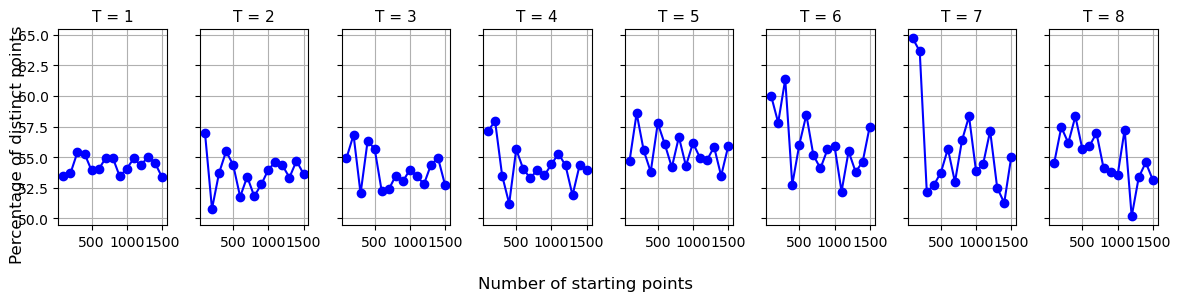

In [94]:
with open('./Ex6PVIT.json') as f:
    dataT= json.load(f)
    
    
T_list= [1, 2, 3, 4, 5, 6, 7, 8] # T= 1 is the one giving meaningfull solution[1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)




for T in T_list:
    data_all= []

    for i in range(len(number_points_list)):
        res_= []
        # print(dataT[str(T)][i])

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            # print(data[str(i)])
            for t in range(len(dataT[str(T)][i])):
                #print(dataT[str(T)][i][t])
                # print(data[str(i)][t])
                if type(dataT[str(T)][i][t]) is not float:
                    if np.abs(constraint_function(dataT[str(T)][i][t]))< 1e-4:
                        res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all
    
    
res_all= []

for i in range(len(number_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)
    
data_all= res_all


dt_res= []

for i in range(len(number_points_list)):
    cleaned_data = [x for x in data_all[i] if x != []]
    # print(cleaned_data)
    dt_res.append(cleaned_data)
    # break

data_all= dt_res


import numpy as np

def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    if num_points>0:
        tolerance = 1/num_points
    else:
        tolerance= 1
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        
        if len(points)>1:
            for distinct_point in distinct_points:
                if calculate_distance(point, distinct_point) < ep:
                    is_distinct = False
                    break
        else:
            is_distinct = False
            break
            
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points



res_T= {
    1: None, 2: None, 3: None, 4: None, 5: None, 6: None, 7: None, 8: None
}
Tmax= 8

dist_= None
for t in range(1, Tmax+1):
    dist_= []

    for (idx, pt) in enumerate(number_points_list):


        num, distinct_points = count_repeated_points(np.array(data_dict[t][idx]))
        distinct_points= np.array(distinct_points)
        dist_.append((len(distinct_points)/(len(np.array(data_dict[t][idx]))))*100)
    res_T[t]= dist_

    
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(100, 1501, 100)

fig, axes = plt.subplots(1, Tmax, figsize=(12,3), sharex=True, sharey=True)

for T in range(1, Tmax+1):
    print(T)
    ax = axes[T-1]
    ax.plot(x, res_T[T], marker='o', c= 'blue')
    ax.set_title(f"T = {T}", fontsize=11)
    ax.grid(True)

# global labels
fig.supxlabel("Number of starting points", fontsize=12)
fig.supylabel("Percentage of distinct points", fontsize=12)

plt.tight_layout()
#plt.savefig("Ex6Tmax.png", dpi=300, bbox_inches="tight")
plt.show()

In [95]:
# res_T

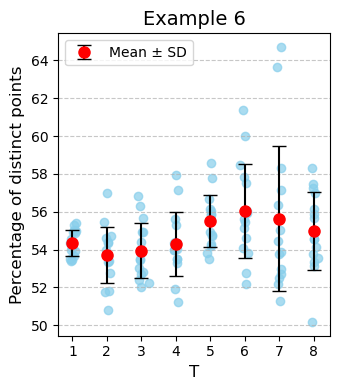

In [97]:
# Compute mean and std for each key
keys = list(res_T.keys())
means = [np.mean(res_T[k]) for k in keys]
stds = [np.std(res_T[k]) for k in keys]

plt.figure(figsize=(3.5,4))

# Plot all points with some horizontal jitter
for i, k in enumerate(keys):
    y = res_T[k]
    x = np.random.normal(loc=i+1, scale=0.05, size=len(y))  # jitter for visibility
    plt.scatter(x, y, color='skyblue', alpha=0.7, label='_nolegend_')

# Overlay mean as a red marker with error bars
plt.errorbar(keys, means, yerr=stds, fmt='o', color='red', ecolor='black', elinewidth=1.5,
             capsize=5, markersize=8, label='Mean ± SD')

# Formatting
plt.xticks(keys)
plt.xlabel('T', fontsize=12)
plt.ylabel('Percentage of distinct points', fontsize=12) # mean PDP across the number of starting points.
plt.title('Example 6', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig("Ex6Tmax.png", dpi=300, bbox_inches="tight")
plt.show()